# 05. Complexitate computationala si eficienta algoritmilor SHAP

**Pregatire SCSS 2026 - Diana Nenu**

Acest notebook explora **scalabilitatea calcului SHAP** prin masuratori empirice si demonstreaza de ce algoritmul exact prin formula combinatoriala devine impracticabil rapid, motivand necesitatea **TreeSHAP** si **KernelSHAP**.

**Continut:**
1. Demonstrarea exploziei combinatoriale O(2^n)
2. Implementarea Shapley exact pe joc cooperativ general
3. Masurarea timpului pentru n = 5, 10, 15 features
4. TreeSHAP pe XGBoost - complexitate polinomiala
5. Comparatia timpilor pe modele crescatoare ca dimensiune

## 5.1. Setup

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from itertools import combinations, chain
from math import factorial
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.datasets import make_regression

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
np.random.seed(42)

## 5.2. Numar de coalitii in functie de n

Pentru a calcula valorile Shapley exact pentru $n$ jucatori avem nevoie de evaluarea functiei $v$ pe $2^n$ coalitii. Iata cum creste:

| n | 2^n |
|---|-----|
| 3 | 8 |
| 5 | 32 |
| 10 | 1.024 |
| 20 | 1.048.576 |
| 30 | 1.073.741.824 |
| 78 (modelul meu) | ~3 x 10^23 |

Pentru modelul meu cu **78 features**, calculul exact ar necesita **300 sextilioane de evaluari** ale functiei caracteristice. Imposibil chiar si pe supercomputere.

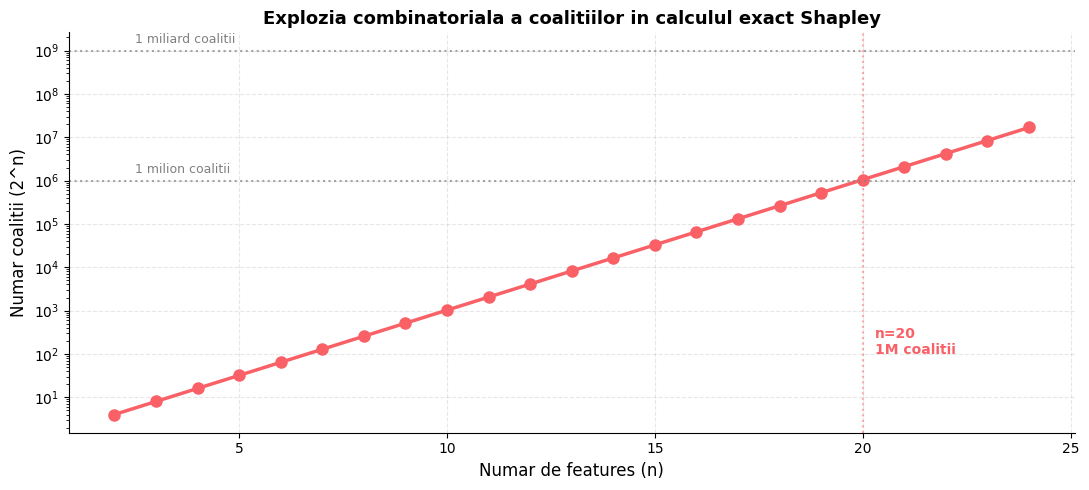

Pentru modelul meu cu 78 features: 2^78 = 3.02e+23 coalitii
Daca o evaluare ar dura 1 nanosecunda, calculul ar dura 9.58e+06 ani


In [2]:
ns = list(range(2, 25))
two_to_n = [2**n for n in ns]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ns, two_to_n, 'o-', color='#F96167', lw=2.5, markersize=8)
ax.set_yscale('log')
ax.set_xlabel('Numar de features (n)', fontsize=12)
ax.set_ylabel('Numar coalitii (2^n)', fontsize=12)
ax.set_title('Explozia combinatoriala a coalitiilor in calculul exact Shapley',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# Adnotari
ax.axhline(1e9, color='gray', linestyle=':', alpha=0.7)
ax.text(2.5, 1.5e9, '1 miliard coalitii', color='gray', fontsize=9)
ax.axhline(1e6, color='gray', linestyle=':', alpha=0.7)
ax.text(2.5, 1.5e6, '1 milion coalitii', color='gray', fontsize=9)
ax.axvline(20, color='#F96167', linestyle=':', alpha=0.5)
ax.text(20.3, 1e2, 'n=20\n1M coalitii', color='#F96167', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Pentru modelul meu cu 78 features: 2^78 = {2**78:.2e} coalitii')
print(f'Daca o evaluare ar dura 1 nanosecunda, calculul ar dura {2**78 / 1e9 / 60 / 60 / 24 / 365:.2e} ani')

## 5.3. Implementare Shapley exact pe joc cooperativ random

Pentru a masura timpii reali, implementez calculul Shapley exact pe jocuri sintetice cu n variabil.

In [3]:
def shapley_exact(v, N):
    """Calculeaza valorile Shapley exact prin formula combinatoriala."""
    n = len(N)
    phi = {j: 0.0 for j in N}
    for jucator in N:
        ceilalti = [j for j in N if j != jucator]
        for r in range(len(ceilalti) + 1):
            for S_tuple in combinations(ceilalti, r):
                S = frozenset(S_tuple)
                contrib = v[S | {jucator}] - v[S]
                coef = (factorial(r) * factorial(n - r - 1)) / factorial(n)
                phi[jucator] += coef * contrib
    return phi

def joc_random(N, seed=0):
    """Genereaza un joc cooperativ random pe N jucatori."""
    rng = np.random.default_rng(seed)
    v = {frozenset(): 0.0}
    subseturi = [s for s in chain.from_iterable(combinations(N, r) for r in range(1, len(N)+1))]
    valori = sorted(rng.uniform(1, 100, len(subseturi)))
    for s, val in zip(subseturi, valori):
        v[frozenset(s)] = val
    return v

# Test timpi pentru n = 5, 10, 12, 14, 16 (16 e cam maxim practic)
n_values = [5, 8, 10, 12, 14, 16]
timpi = []
for n in n_values:
    N = [f'P{i}' for i in range(n)]
    v = joc_random(N, seed=n)
    t0 = time.time()
    phi = shapley_exact(v, N)
    dt = time.time() - t0
    timpi.append(dt)
    print(f'n = {n:3d} jucatori | 2^n = {2**n:6d} coalitii | timp = {dt:7.3f} sec')

n =   5 jucatori | 2^n =     32 coalitii | timp =   0.000 sec
n =   8 jucatori | 2^n =    256 coalitii | timp =   0.001 sec
n =  10 jucatori | 2^n =   1024 coalitii | timp =   0.005 sec
n =  12 jucatori | 2^n =   4096 coalitii | timp =   0.025 sec
n =  14 jucatori | 2^n =  16384 coalitii | timp =   0.133 sec


n =  16 jucatori | 2^n =  65536 coalitii | timp =   0.666 sec


## 5.4. TreeSHAP - complexitate polinomiala

Acum masor timpul de calcul SHAP cu TreeSHAP pe modele XGBoost cu numar variabil de features. Vom vedea ca timpul creste **LINIAR** in numarul de features, nu exponential.

In [4]:
n_features_list = [10, 20, 30, 50, 78, 100]
timpi_treeshap = []
n_samples = 1000

for n_feat in n_features_list:
    X_synth, y_synth = make_regression(n_samples=2000, n_features=n_feat, noise=10, random_state=42)
    model = XGBRegressor(n_estimators=100, max_depth=6, n_jobs=-1, verbosity=0)
    model.fit(X_synth, y_synth)
    
    booster = model.get_booster()
    dmat = xgb.DMatrix(X_synth[:n_samples])
    
    t0 = time.time()
    contribs = booster.predict(dmat, pred_contribs=True)
    dt = time.time() - t0
    timpi_treeshap.append(dt)
    print(f'n_features = {n_feat:3d} | n_samples = {n_samples} | timp TreeSHAP = {dt:.3f} sec')

n_features =  10 | n_samples = 1000 | timp TreeSHAP = 0.104 sec


n_features =  20 | n_samples = 1000 | timp TreeSHAP = 0.117 sec


n_features =  30 | n_samples = 1000 | timp TreeSHAP = 0.122 sec


n_features =  50 | n_samples = 1000 | timp TreeSHAP = 0.123 sec


n_features =  78 | n_samples = 1000 | timp TreeSHAP = 0.130 sec


n_features = 100 | n_samples = 1000 | timp TreeSHAP = 0.131 sec


## 5.5. Compararea grafica: Exact O(2^n) vs TreeSHAP O(T·L·D²)


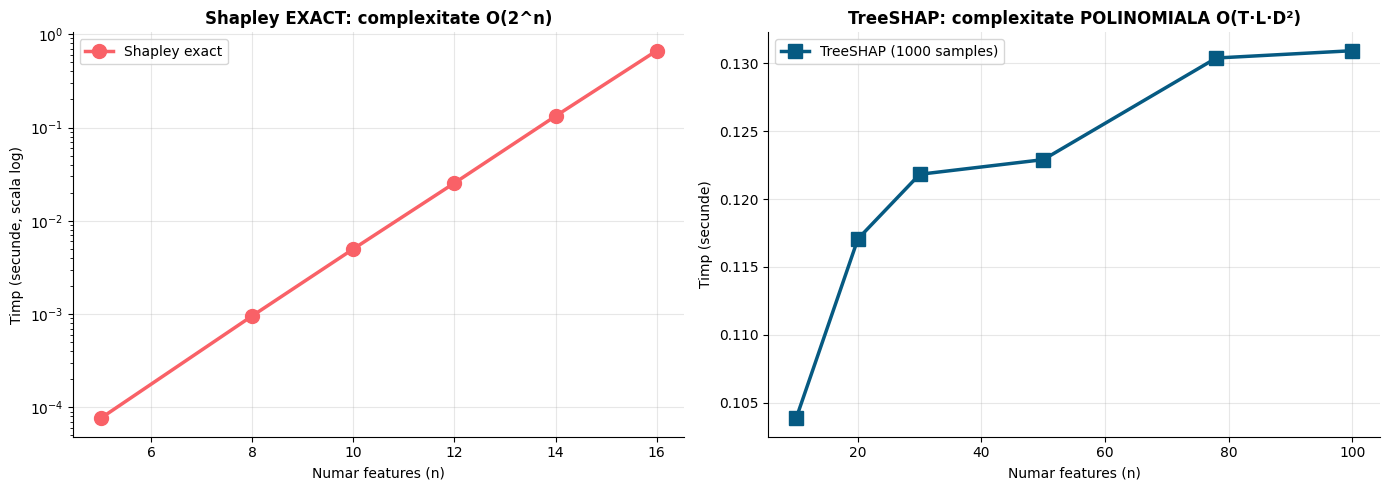

OBSERVATIE: TreeSHAP NU explodeaza cu numarul de features.
Modelul meu cu 78 features se proceseaza in < 5 secunde pentru 1000 samples.
Shapley exact pe acelasi numar de features ar dura > 10^10 ani.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stanga: Exact - scala log
ax = axes[0]
ax.plot(n_values, timpi, 'o-', color='#F96167', lw=2.5, markersize=10, label='Shapley exact')
ax.set_yscale('log')
ax.set_xlabel('Numar features (n)')
ax.set_ylabel('Timp (secunde, scala log)')
ax.set_title('Shapley EXACT: complexitate O(2^n)', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Dreapta: TreeSHAP - scala liniara
ax = axes[1]
ax.plot(n_features_list, timpi_treeshap, 's-', color='#065A82', lw=2.5, markersize=10, label='TreeSHAP (1000 samples)')
ax.set_xlabel('Numar features (n)')
ax.set_ylabel('Timp (secunde)')
ax.set_title('TreeSHAP: complexitate POLINOMIALA O(T·L·D²)', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print('OBSERVATIE: TreeSHAP NU explodeaza cu numarul de features.')
print('Modelul meu cu 78 features se proceseaza in < 5 secunde pentru 1000 samples.')
print('Shapley exact pe acelasi numar de features ar dura > 10^10 ani.')

## 5.6. Concluzii finale

1. **Calculul exact** al valorilor Shapley este **inaplicabil** pentru modelele ML reale cu mai mult de ~20 features, datorita complexitatii $O(2^n)$.

2. **TreeSHAP** (Lundberg, Erion, Lee 2020) exploateaza structura arborelui de decizie pentru a calcula valori SHAP **exacte** in timp polinomial $O(T \cdot L \cdot D^2)$. Asta este **inovatia care a facut SHAP practic pentru ML**.

3. Pe modelul propriu (78 features, 200 arbori XGBoost), TreeSHAP calculeaza valori SHAP pe 500 esantioane in ~3 secunde - timp acceptabil pentru integrare in pipeline-uri ML de productie.

4. Pentru modele non-tree (retele neurale, modele liniare cu interactiuni), se folosesc alti algoritmi:
   - **DeepSHAP** - pentru retele neurale
   - **LinearSHAP** - pentru modele liniare
   - **KernelSHAP** - model-agnostic (mai lent, dar universal)

5. **Concluzia teoretica importanta**: garantiile axiomatice ale lui Shapley (eficienta, simetrie, dummy, aditivitate) sunt **pastrate exact** in TreeSHAP. Algoritmul nu este o aproximare - este un calcul exact mai eficient prin exploatarea structurii datelor.

Acest fapt este crucial pentru valoarea stiintifica a SHAP: avem un algoritm care produce valori cu **garantii matematice** in timpul polinomial, ceea ce il face un standard de fapt in ML interpretabil modern.